In [51]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [52]:
import os

PROJECT_DIR = "/content/drive/MyDrive/Titanic_Project/analytics"

os.makedirs(PROJECT_DIR, exist_ok=True)

print(PROJECT_DIR)

/content/drive/MyDrive/Titanic_Project/analytics


In [53]:
import os
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42

# Paths
ANALYTICS_DIR = os.path.abspath(".")
FIGURES_DIR = os.path.join(ANALYTICS_DIR, "figures")

os.makedirs(FIGURES_DIR, exist_ok=True)

print("Analytics directory:", ANALYTICS_DIR)
print("Figures directory:", FIGURES_DIR)

Analytics directory: /content
Figures directory: /content/figures


In [54]:
import seaborn as sns

df = sns.load_dataset("titanic")

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.head()

Dataset loaded successfully.
Rows: 891
Columns: 15


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [55]:
fallback_path = os.path.join(ANALYTICS_DIR, "titanic.csv")

df.to_csv(fallback_path, index=False)

print(f"Offline fallback saved to: {fallback_path}")
print("File shape:", pd.read_csv(fallback_path).shape)

Offline fallback saved to: /content/titanic.csv
File shape: (891, 15)


In [56]:
print("========== INFO ==========")
df.info()

print("\n========== DESCRIBE ==========")
display(df.describe(include="all").T)

print("\n========== SHAPE ==========")
print(df.shape)

========== INFO ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

========== DESCRIBE ==========


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,891,3,Third,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
who,891,3,man,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN



========== SHAPE ==========
(891, 15)


In [57]:
missing_counts = df.isna().sum()
missing_percent = (df.isna().mean() * 100).round(2)

missing_report = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percentage": missing_percent
})

missing_report = missing_report[
    missing_report["missing_count"] > 0
].sort_values(
    "missing_percentage",
    ascending=False
)

print("Columns containing missing values:")
display(missing_report)

Columns containing missing values:


,missing_count,missing_percentage
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


In [58]:
clean_df = df.copy()

# Calculate missing percentages
missing_pct = clean_df.isna().mean() * 100

# Columns with >30% missing values are dropped
drop_columns = missing_pct[missing_pct > 30].index.tolist()

print("Columns dropped because missingness > 30%:")
print(drop_columns)

clean_df = clean_df.drop(columns=drop_columns)

# Numeric columns:
# Median imputation is robust to skew and outliers.
numeric_columns = clean_df.select_dtypes(
    include=["number"]
).columns.tolist()

for column in numeric_columns:
    if clean_df[column].isna().any():
        median_value = clean_df[column].median()
        clean_df[column] = clean_df[column].fillna(median_value)
        print(
            f"Filled numeric column '{column}' "
            f"using median = {median_value:.4f}"
        )

# Categorical columns:
# Mode is appropriate for small amounts of missing categorical data.
categorical_columns = clean_df.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

for column in categorical_columns:
    if clean_df[column].isna().any():
        mode_value = clean_df[column].mode(dropna=True)[0]
        clean_df[column] = clean_df[column].fillna(mode_value)
        print(
            f"Filled categorical column '{column}' "
            f"using mode = {mode_value}"
        )

print("\nRemaining missing values:")
display(clean_df.isna().sum())

Columns dropped because missingness > 30%:
['deck']
Filled numeric column 'age' using median = 28.0000
Filled categorical column 'embarked' using mode = S
Filled categorical column 'embark_town' using mode = Southampton

Remaining missing values:


,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


In [59]:
strategy_rows = []

for column in df.columns:

    missing_count = df[column].isna().sum()
    missing_pct = df[column].isna().mean() * 100

    if missing_count == 0:

        threshold_band = "0%"

        strategy = "No action"

        reason = (
            "The column contains no missing values, so no "
            "missing-value treatment is required."
        )

    elif missing_pct < 5:

        threshold_band = "<5%"

        if pd.api.types.is_numeric_dtype(df[column]):

            strategy = "Median imputation"

            reason = (
                f"{missing_pct:.2f}% of values are missing, which is "
                "below the 5% threshold. Median imputation is used for "
                "the numeric variable because it is robust to skew and "
                "potential outliers."
            )

        else:

            strategy = "Mode imputation"

            reason = (
                f"{missing_pct:.2f}% of values are missing, which is "
                "below the 5% threshold. Mode imputation is used for "
                "the categorical variable because the missing fraction "
                "is very small."
            )

    elif missing_pct <= 30:

        threshold_band = "5–30%"

        if pd.api.types.is_numeric_dtype(df[column]):

            strategy = "Median imputation"

            reason = (
                f"{missing_pct:.2f}% of values are missing, which falls "
                "within the 5–30% range. Median imputation is preferred "
                "for this numeric variable because it is robust to "
                "skew and extreme observations."
            )

        else:

            strategy = "Mode imputation"

            reason = (
                f"{missing_pct:.2f}% of values are missing, which falls "
                "within the 5–30% range. Mode imputation is used for "
                "the categorical variable to preserve the dominant "
                "category."
            )

    else:

        threshold_band = ">30%"

        strategy = "Drop column"

        reason = (
            f"{missing_pct:.2f}% of values are missing, exceeding the "
            "30% threshold. The column is dropped because imputing such "
            "a large proportion of values could introduce substantial "
            "artificial information."
        )

    strategy_rows.append({
        "column": column,
        "missing_count": missing_count,
        "missing_percentage": round(missing_pct, 2),
        "threshold_band": threshold_band,
        "strategy": strategy,
        "justification": reason
    })


strategy_report = pd.DataFrame(strategy_rows)

print("Percentage-based missing-value strategy:")
display(strategy_report)

Percentage-based missing-value strategy:


,column,missing_count,missing_percentage,threshold_band,strategy,justification
0,survived,0,0.00,0%,No action,"The column contains no missing values, so no m..."
1,pclass,0,0.00,0%,No action,"The column contains no missing values, so no m..."
2,sex,0,0.00,0%,No action,"The column contains no missing values, so no m..."
3,age,177,19.87,5–30%,Median imputation,"19.87% of values are missing, which falls with..."
4,sibsp,0,0.00,0%,No action,"The column contains no missing values, so no m..."
5,parch,0,0.00,0%,No action,"The column contains no missing values, so no m..."
6,fare,0,0.00,0%,No action,"The column contains no missing values, so no m..."
7,embarked,2,0.22,<5%,Mode imputation,"0.22% of values are missing, which is below th..."
8,class,0,0.00,0%,No action,"The column contains no missing values, so no m..."
9,who,0,0.00,0%,No action,"The column contains no missing values, so no m..."


In [60]:
print("Original shape:", df.shape)
print("Cleaned shape :", clean_df.shape)

print("\nData types:")
display(clean_df.dtypes)

print("\nRemaining missing values:")
print(clean_df.isna().sum().sum())

Original shape: (891, 15)
Cleaned shape : (891, 14)

Data types:


,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,category
who,object



Remaining missing values:
0


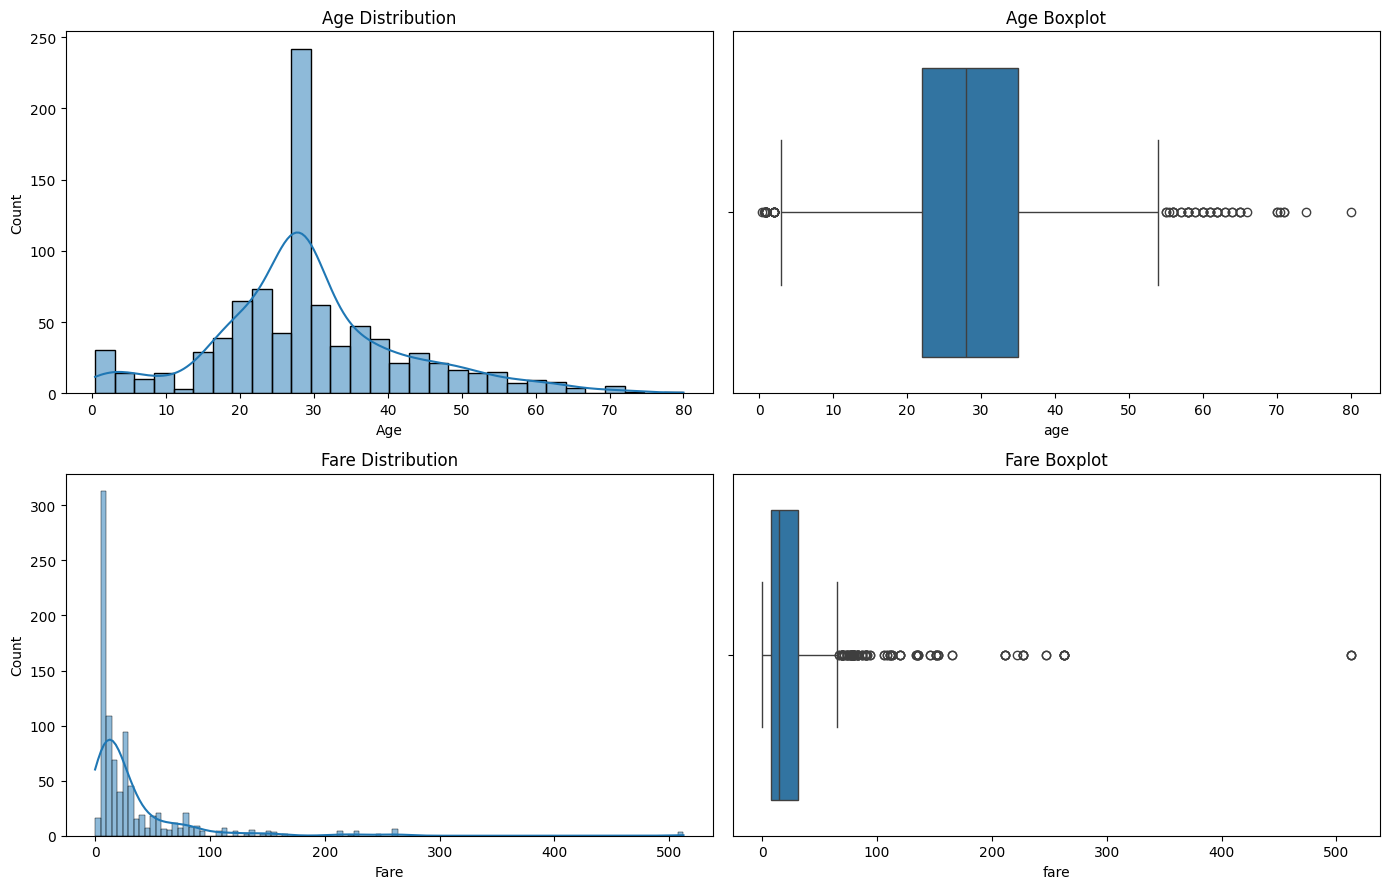

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.histplot(clean_df["age"], kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Age Distribution")
axes[0, 0].set_xlabel("Age")

sns.boxplot(x=clean_df["age"], ax=axes[0, 1])
axes[0, 1].set_title("Age Boxplot")


sns.histplot(clean_df["fare"], kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Fare Distribution")
axes[1, 0].set_xlabel("Fare")


sns.boxplot(x=clean_df["fare"], ax=axes[1, 1])
axes[1, 1].set_title("Fare Boxplot")

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURES_DIR, "age_fare_distributions.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [62]:
def iqr_outlier_count(series):
    """
    Return the number of observations outside:
    [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
    """
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = (series < lower_bound) | (series > upper_bound)

    return {
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": int(outliers.sum())
    }


age_outliers = iqr_outlier_count(clean_df["age"])
fare_outliers = iqr_outlier_count(clean_df["fare"])

outlier_report = pd.DataFrame({
    "age": age_outliers,
    "fare": fare_outliers
}).T

display(outlier_report)

,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count
age,22.0000,35.0,13.0000,2.500,54.5000,66.0
fare,7.9104,31.0,23.0896,-26.724,65.6344,116.0


In [63]:
distribution_rows = []

for column in ["age", "fare"]:

    series = clean_df[column]

    mean_value = series.mean()
    median_value = series.median()

    mode_values = series.mode()

    # There can be more than one mode
    mode_value = mode_values.iloc[0]

    skewness = series.skew()

    if skewness > 0.5:
        shape = "Right-skewed"
    elif skewness < -0.5:
        shape = "Left-skewed"
    else:
        shape = "Approximately symmetric"

    distribution_rows.append({
        "variable": column,
        "mean": mean_value,
        "median": median_value,
        "mode": mode_value,
        "skewness": skewness,
        "distribution": shape
    })

distribution_report = pd.DataFrame(distribution_rows)

display(distribution_report)

,variable,mean,median,mode,skewness,distribution
0,age,29.361582,28.0000,28.00,0.510245,Right-skewed
1,fare,32.204208,14.4542,8.05,4.787317,Right-skewed


In [64]:
sex_survival = (
    clean_df.groupby("sex")["survived"]
    .mean()
    .mul(100)
    .round(2)
)

class_survival = (
    clean_df.groupby("pclass")["survived"]
    .mean()
    .mul(100)
    .round(2)
)

sex_class_survival = (
    clean_df.groupby(["sex", "pclass"])["survived"]
    .mean()
    .mul(100)
    .round(2)
)

print("Survival rate by sex (%):")
display(sex_survival)

print("Survival rate by passenger class (%):")
display(class_survival)

print("Survival rate by sex and class (%):")
display(sex_class_survival)

Survival rate by sex (%):


,survived
sex,
female,74.20
male,18.89


Survival rate by passenger class (%):


,survived
pclass,
1,62.96
2,47.28
3,24.24


Survival rate by sex and class (%):


sex     pclass
female  1         96.81
        2         92.11
        3         50.00
male    1         36.89
        2         15.74
        3         13.54
Name: survived, dtype: float64

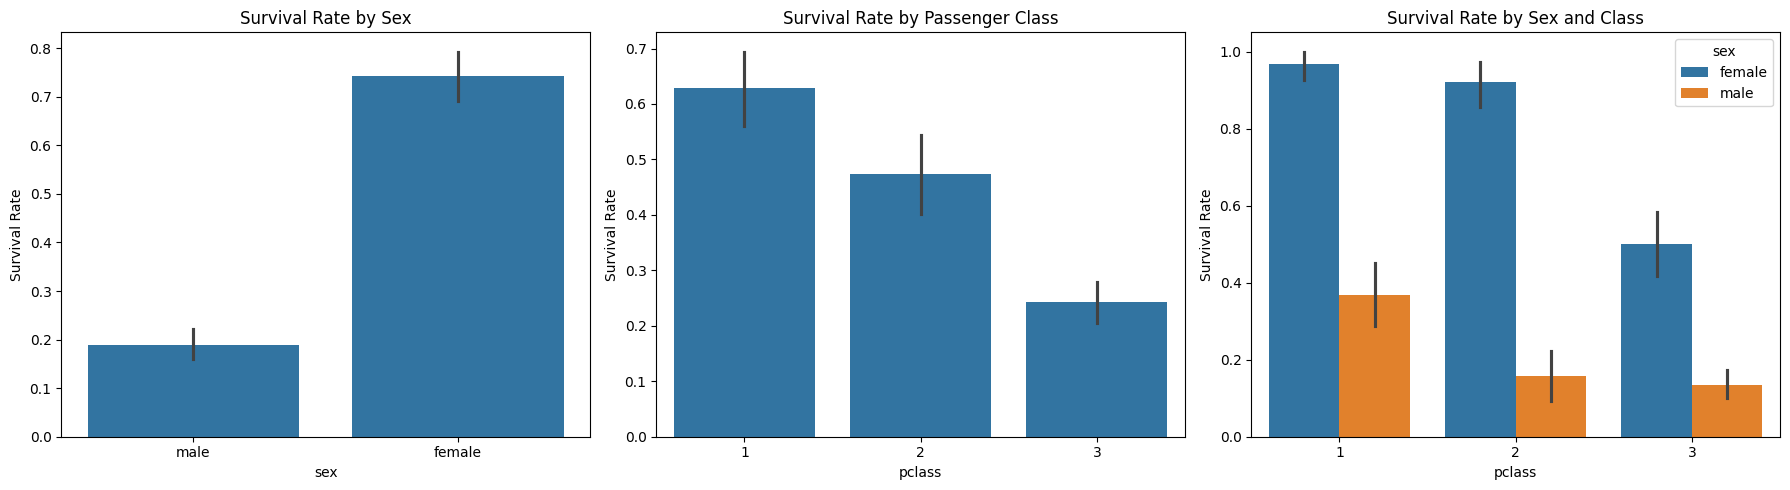

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(
    data=clean_df,
    x="sex",
    y="survived",
    ax=axes[0]
)

axes[0].set_title("Survival Rate by Sex")
axes[0].set_ylabel("Survival Rate")

sns.barplot(
    data=clean_df,
    x="pclass",
    y="survived",
    ax=axes[1]
)

axes[1].set_title("Survival Rate by Passenger Class")
axes[1].set_ylabel("Survival Rate")

sns.barplot(
    data=clean_df,
    x="pclass",
    y="survived",
    hue="sex",
    ax=axes[2]
)

axes[2].set_title("Survival Rate by Sex and Class")
axes[2].set_ylabel("Survival Rate")

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURES_DIR, "survival_bivariate_analysis.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [66]:
correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

correlation_matrix = clean_df[correlation_columns].corr()

print("Correlation matrix:")
display(correlation_matrix)

Correlation matrix:


,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307
pclass,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500
age,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688
sibsp,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651
parch,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225
fare,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000


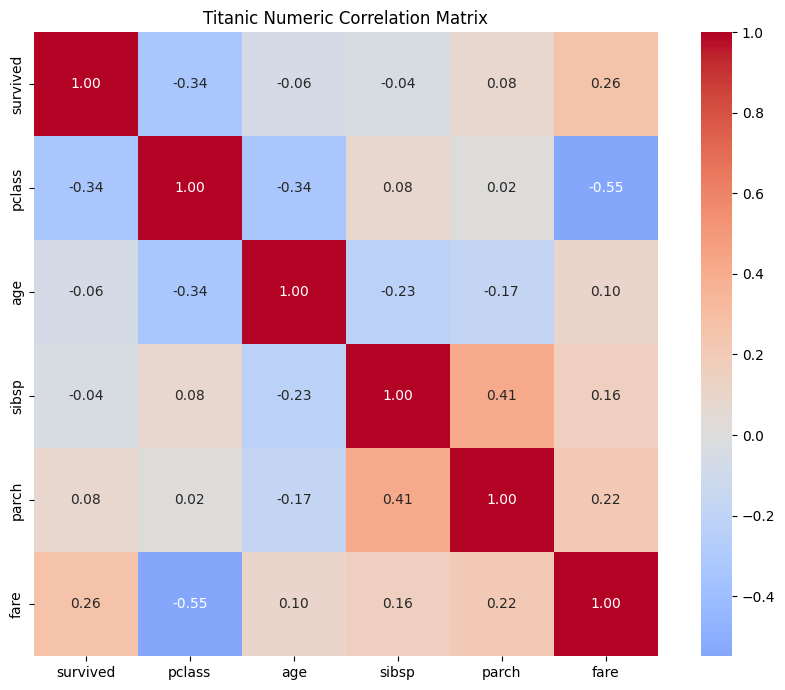

In [67]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Titanic Numeric Correlation Matrix")

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURES_DIR, "correlation_heatmap.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [68]:
corr_pairs = []

for i in range(len(correlation_columns)):
    for j in range(i + 1, len(correlation_columns)):

        col1 = correlation_columns[i]
        col2 = correlation_columns[j]

        corr_value = correlation_matrix.loc[col1, col2]

        corr_pairs.append({
            "feature_1": col1,
            "feature_2": col2,
            "correlation": corr_value,
            "absolute_correlation": abs(corr_value)
        })

corr_pairs_df = pd.DataFrame(corr_pairs)

top_two_correlations = (
    corr_pairs_df
    .sort_values("absolute_correlation", ascending=False)
    .head(2)
)

print("Two strongest feature relationships:")
display(top_two_correlations)

Two strongest feature relationships:


,feature_1,feature_2,correlation,absolute_correlation
8,pclass,fare,-0.549500,0.549500
12,sibsp,parch,0.414838,0.414838


In [69]:
def interpret_correlation(r):
    abs_r = abs(r)

    if abs_r >= 0.7:
        strength = "very strong"
    elif abs_r >= 0.5:
        strength = "strong"
    elif abs_r >= 0.3:
        strength = "moderate"
    elif abs_r >= 0.1:
        strength = "weak"
    else:
        strength = "very weak"

    direction = "positive" if r > 0 else "negative"

    return f"{strength} {direction} relationship"


for _, row in top_two_correlations.iterrows():

    interpretation = interpret_correlation(row["correlation"])

    print(
        f"{row['feature_1']} vs {row['feature_2']}: "
        f"r = {row['correlation']:.3f} — {interpretation}."
    )

print(
    "\nInterpretation: correlation measures linear association and does "
    "not establish causation. The strongest relationships should be "
    "discussed in the context of passenger class, fare and survival."
)

pclass vs fare: r = -0.549 — strong negative relationship.
sibsp vs parch: r = 0.415 — moderate positive relationship.

Interpretation: correlation measures linear association and does not establish causation. The strongest relationships should be discussed in the context of passenger class, fare and survival.


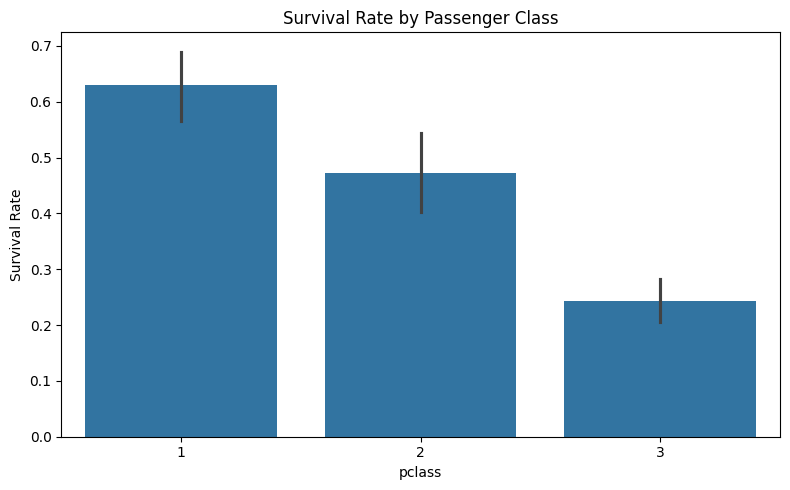

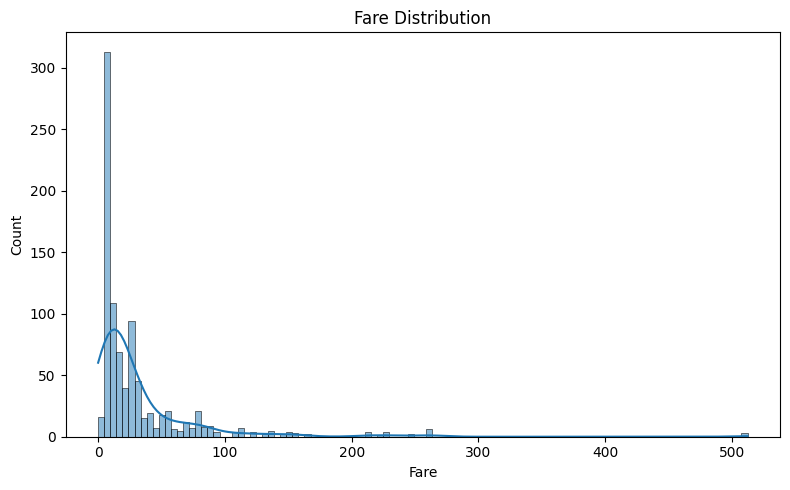

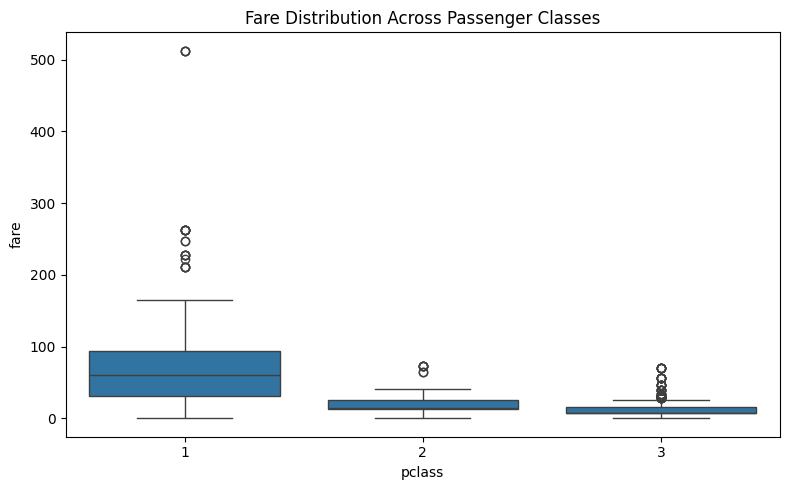

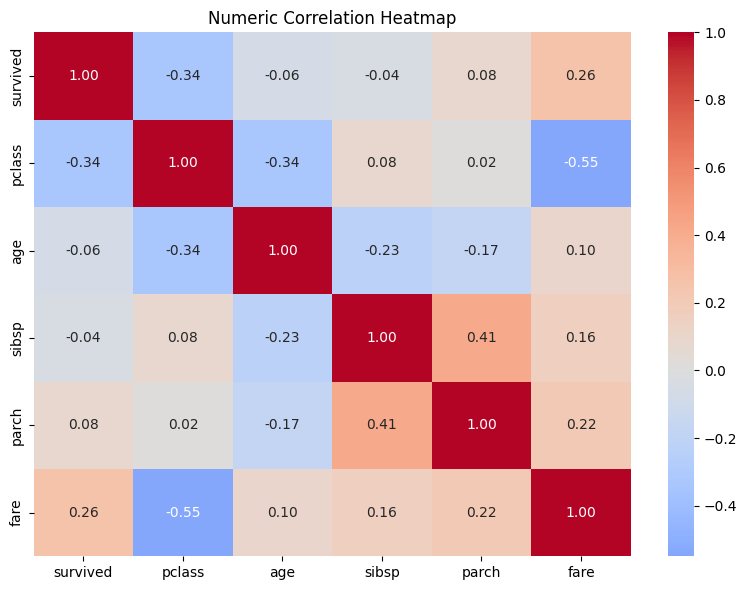

In [70]:
# Chart 1: Bar chart
plt.figure(figsize=(8, 5))

sns.barplot(
    data=clean_df,
    x="pclass",
    y="survived"
)

plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURES_DIR, "chart_1_bar.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# Chart 2: Histogram
plt.figure(figsize=(8, 5))

sns.histplot(
    data=clean_df,
    x="fare",
    kde=True
)

plt.title("Fare Distribution")
plt.xlabel("Fare")

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURES_DIR, "chart_2_histogram.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# Chart 3: Boxplot
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=clean_df,
    x="pclass",
    y="fare"
)

plt.title("Fare Distribution Across Passenger Classes")

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURES_DIR, "chart_3_boxplot.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# Chart 4: Heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Numeric Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURES_DIR, "chart_4_heatmap.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [71]:
eda_scaled = clean_df.copy()

scaler_eda = StandardScaler()

eda_scaled[["age_z", "fare_z"]] = scaler_eda.fit_transform(
    clean_df[["age", "fare"]]
)

print("Original statistics:")
display(clean_df[["age", "fare"]].agg(["mean", "std"]))

print("\nZ-score statistics:")
display(eda_scaled[["age_z", "fare_z"]].agg(["mean", "std"]))

Original statistics:


,age,fare
mean,29.361582,32.204208
std,13.019697,49.693429



Z-score statistics:


,age_z,fare_z
mean,2.272780e-16,3.987333e-18
std,1.000562e+00,1.000562e+00


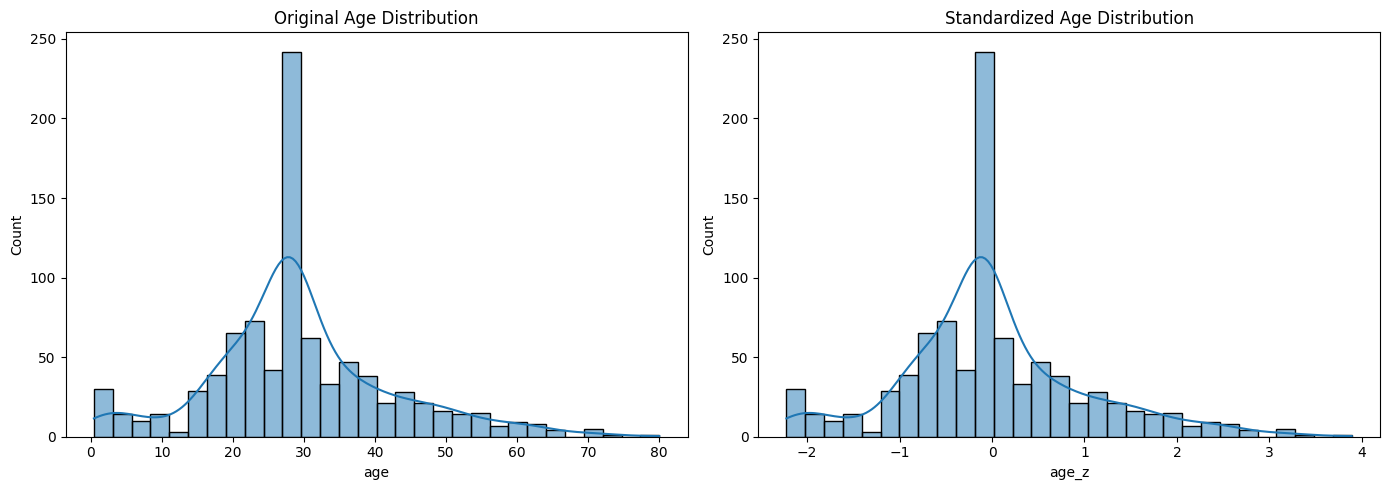

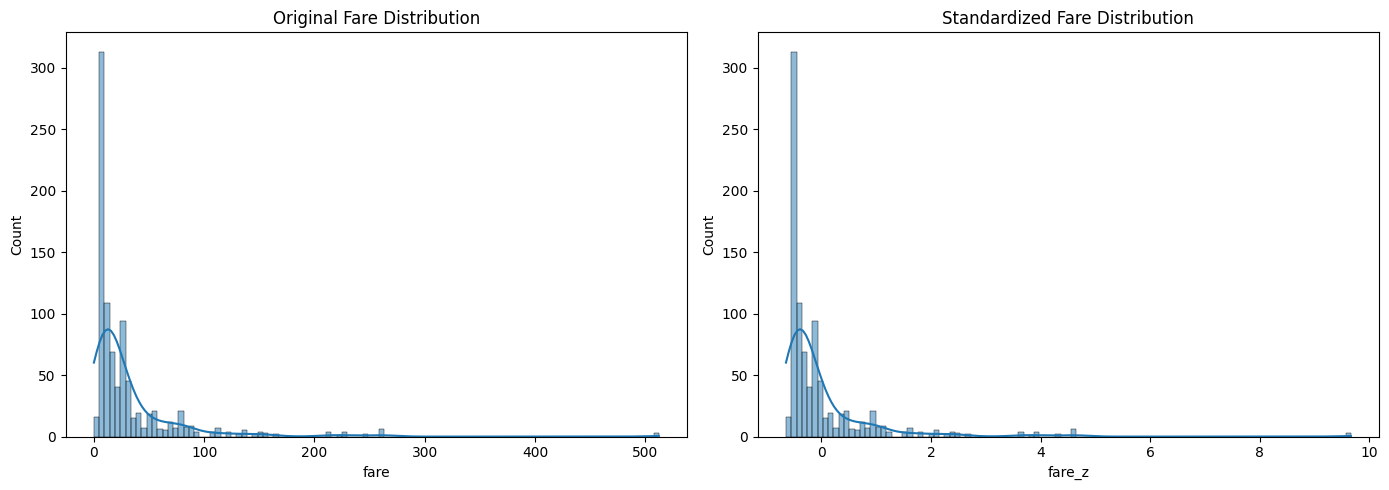

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    clean_df["age"],
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Original Age Distribution")

sns.histplot(
    eda_scaled["age_z"],
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Standardized Age Distribution")

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURES_DIR, "age_standardization.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    clean_df["fare"],
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Original Fare Distribution")

sns.histplot(
    eda_scaled["fare_z"],
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Standardized Fare Distribution")

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURES_DIR, "fare_standardization.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [73]:
# FINAL DATA STORAGE

cleaned_path = os.path.join(
    ANALYTICS_DIR,
    "titanic_cleaned.csv"
)

clean_df.to_csv(
    cleaned_path,
    index=False
)

print("Cleaned dataset saved to:")
print(cleaned_path)

print("\nFinal cleaned shape:")
print(clean_df.shape)

print("\nRemaining missing values:")
print(clean_df.isna().sum().sum())

Cleaned dataset saved to:
/content/titanic_cleaned.csv

Final cleaned shape:
(891, 14)

Remaining missing values:
0


In [74]:
cleaned_path = os.path.join(
    PROJECT_DIR,
    "titanic_cleaned.csv"
)

clean_df.to_csv(
    cleaned_path,
    index=False
)

print("Cleaned CSV saved successfully:")
print(cleaned_path)

Cleaned CSV saved successfully:
/content/drive/MyDrive/Titanic_Project/analytics/titanic_cleaned.csv
